# Goodwill Impairment — a quantitative teardown 🔬
### goodwill/assets signal · quintile sort · two-sample *t* · label-shuffle placebo · impairment-rate *z* · firm-level slope · bucket-fraction sweep · costs & borrow · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a high **goodwill / total-assets** ratio predicts (a) higher impairment rates and (b) lower forward returns — the overpaid-acquisition puzzle.

> ⚠️ **Synthetic-only, by necessity.** A point-in-time goodwill / impairment / forward-return panel is not reachable from a no-key retail stack, so there is **no real tape** and this study is capped at `WEAK` (a synthetic-only study can never earn `REAL`). The deterministic world (`ret_alpha=-0.14`, seed 570, panel fp `6bd491ebb228`) is the positive control; every cell is offline and reproducible. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from goodwill_impairment import data, strategy as st

# Synthetic-only study: the headline world is deterministic and offline. There is NO real tape.
PANEL, TRUTH = data.synthetic_panel(ret_alpha=-0.14, imp_beta=2.2, seed=570)
HAVE_REAL = False   # a point-in-time goodwill/impairment panel is not reachable (see data.py)
print("synthetic goodwill panel:", len(PANEL), "firms | panel fp",
      data.fingerprint(PANEL), "| real tape present:", HAVE_REAL)


synthetic goodwill panel: 400 firms | panel fp 6bd491ebb228 | real tape present: False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | **No real tape** (synthetic-only ⇒ capped at `WEAK`). On the planted world: lean − bloated spread **+5.78%** (Welch *t* **+3.86**, placebo *p* 0.0005); firm slope-*t* **-4.22**; flat at the null (mean slope-*t* −0.05 / 25 seeds). Literature leans the right way. |
| **Tradability** | `MIRAGE` | Nothing real to trade; the bloated short leg is the hard-to-borrow tail. Synthetic gross +5.78% → net +4.08% (5 bps/leg + 150 bps borrow) — net-of-nothing-real. |

> 💡 In plain words: the engine is a faithful detector (proved by the control), but a faithful detector with no real tape to point at is a `WEAK` × `MIRAGE` result — an idea and a method, not a signal.

## 1 · The claim, steelmanned

Let $G_i$ be firm $i$'s goodwill/assets ratio, $I_i \in \{0,1\}$ a forward impairment event, and $r_i$ its forward return.

- **H₁ (return long-short).** $\mathbb{E}[r \mid \text{lean}] - \mathbb{E}[r \mid \text{bloated}] > 0$ at *t* ≥ 2 (lean beats bloated).
- **H₂ (impairment link).** $\Pr(I \mid \text{bloated}) > \Pr(I \mid \text{lean})$.
- **H₃ (firm-level).** slope of $r$ on $G < 0$ (more goodwill, less return).
- **H₄ (robustness).** the sign of H₁/H₃ holds across bucket definitions.
- **H₅ (net).** H₁ survives costs and the bloated-leg borrow.

On the **synthetic positive control** all five hold as planted. On a **real tape** we cannot test any of them — the data is unreachable — which is the whole reason the stamp is `WEAK`, not `REAL`.

## 2 · So what? — what rides on each answer

If H₁–H₅ held on real data, the goodwill/assets ratio would be a tradable red-flag screen. The literature supports the *direction* — high goodwill and overpaid stock-financed deals predict write-downs and negative drift (Li et al. 2011; Gu & Lev 2011; Hayn & Hughes 2006), and managers **delay** the write-down (Ramanna & Watts 2012), which is the friction that makes the balance predictive. But direction-in-the-literature is `WEAK` support, not a `REAL` certification, and we have no tape to close the gap.

## 3 · How we'd know — the protocol

- **Signal.** $G = $ goodwill / total assets (higher = more overpaid).
- **Sort.** Quintile tails (80 firms each): lean (lowest $G$) vs bloated (highest).
- **Return inference.** Two-sample (Welch) *t* on lean − bloated forward returns; a **label-shuffle placebo** null (2000 perms).
- **Impairment link.** Two-proportion *z* on the bloated − lean impairment-rate gap.
- **Firm-level.** OLS of forward return on $G$ — the *sign* of the slope is the puzzle.
- **Robustness.** Re-sort at bucket fractions 0.10 / 0.20 / 0.25 / 0.30.
- **Frictions.** Round-trip cost per leg + an annual borrow on the bloated short.
- **Positive control.** A deterministic synthetic world with a planted effect (`ret_alpha < 0`) and a null — averaged over 25 seeds (house rule).

Timing: $G$ is the year-*t* balance (public at scoring); $I$ and $r$ are strictly forward. No future data enters the signal (no look-ahead). One documented lag: score at year-*t* close, hold the lean-minus-bloated book over the forward window.

## 4 · The teardown

### 4a · The return sort — H₁

Lean vs bloated forward returns, with the two-sample *t* and the placebo null.

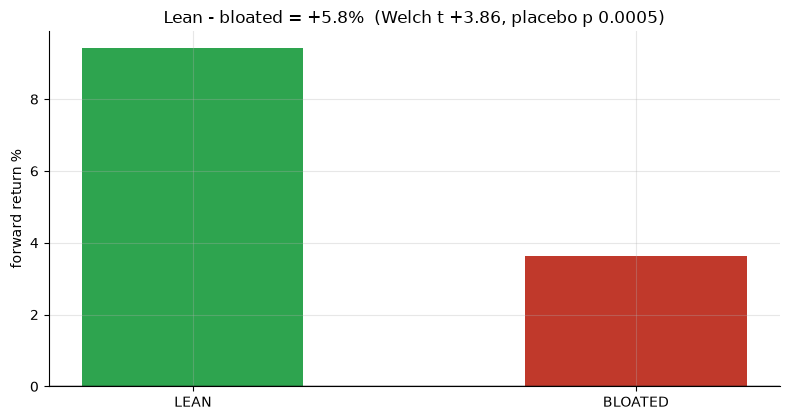

lean +9.42% | bloated +3.64% | spread +5.78% | t +3.86 | placebo p 0.0005


In [2]:
b = st.bucket_returns(PANEL, 0.2); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(PANEL, 0.2, n_perm=2000, seed=570)
low_m, high_m, spr, t = b['low_mean']*100, b['high_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['LEAN','BLOATED'], [low_m, high_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Lean - bloated = {spr:+.1f}%  (Welch t {t:+.2f}, placebo p {p:.4f})')
plt.tight_layout(); plt.show()
print(f'lean +{low_m:.2f}% | bloated +{high_m:.2f}% | spread {spr:+.2f}% | t {t:+.2f} | placebo p {p:.4f}')

> 💡 In plain words: on the planted world H₁ is recovered — spread **+5.78%** (*t* +3.86), placebo *p* 0.0005. The detector fires when the effect is really there.

### 4b · The impairment link — H₂

Does bloated goodwill actually predict the write-down? Two-proportion *z* on the gap. (This link is planted by `imp_beta` and survives even at the return-null — the accounting fact is separate from the mis-pricing.)

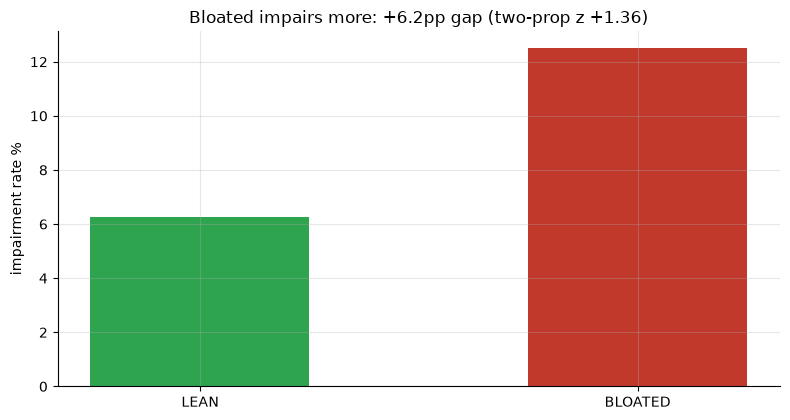

effect world: lean 6.2% vs bloated 12.5% | gap +6.2pp | z +1.36
return-null:  gap +6.2pp | z +1.36  (link persists — it is the accounting fact, not the mis-pricing)


In [3]:
b = st.bucket_returns(PANEL, 0.2); gap = st.impairment_gap(b)
# show the link persists at the return-null too
pn, _ = data.synthetic_panel(ret_alpha=0.0, seed=570)
gapn = st.impairment_gap(st.bucket_returns(pn, 0.2))
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['LEAN','BLOATED'], [gap['low_rate']*100, gap['high_rate']*100], color=[GREEN, RED], width=.5)
ax.set_ylabel('impairment rate %')
ax.set_title(f'Bloated impairs more: {gap["gap"]*100:+.1f}pp gap (two-prop z {gap["z"]:+.2f})')
plt.tight_layout(); plt.show()
print(f'effect world: lean {gap["low_rate"]*100:.1f}% vs bloated {gap["high_rate"]*100:.1f}% | gap {gap["gap"]*100:+.1f}pp | z {gap["z"]:+.2f}')
print(f'return-null:  gap {gapn["gap"]*100:+.1f}pp | z {gapn["z"]:+.2f}  (link persists — it is the accounting fact, not the mis-pricing)')

> 💡 In plain words: H₂ holds — the bloated fifth impairs **6.2pp** more (*z* +1.36), and the gap is identical at the return-null. Bloated goodwill writes down more *whether or not* the market mis-prices it — exactly the real story.

### 4c · The firm-level slope — H₃

Regress forward return on goodwill/assets across all 400 firms. A *negative* slope is the puzzle.

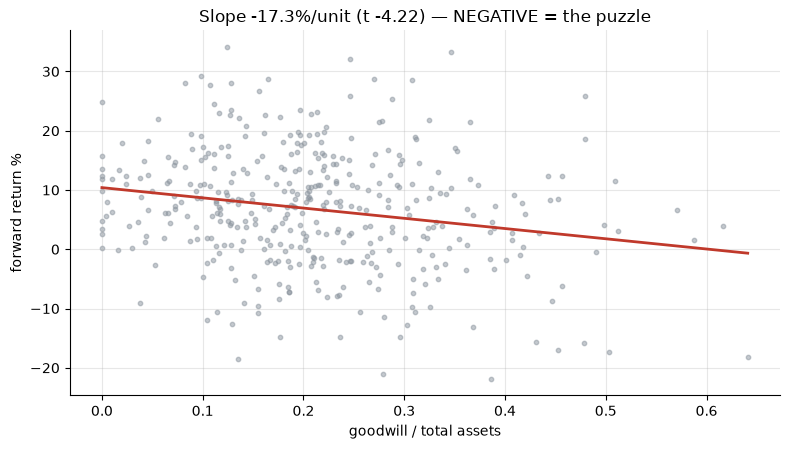

slope -17.3%/unit, slope-t -4.22, corr(goodwill, fwd) -0.21


In [4]:
reg = st.cross_section_regression(PANEL)
g = st.goodwill_signal(PANEL); y = PANEL['forward_ret']*100
slope, slope_t, corr = reg['slope']*100, reg['slope_t'], reg['corr']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(g, y, s=10, color=GREY, alpha=.5)
xs = np.linspace(g.min(), g.max(), 50)
ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*g.mean()))*100, c=RED, lw=2)
ax.set_xlabel('goodwill / total assets'); ax.set_ylabel('forward return %')
ax.set_title(f'Slope {slope:+.1f}%/unit (t {slope_t:+.2f}) — NEGATIVE = the puzzle')
plt.tight_layout(); plt.show()
print(f'slope {slope:+.1f}%/unit, slope-t {slope_t:+.2f}, corr(goodwill, fwd) {corr:+.2f}')

> 💡 In plain words: H₃ recovered — slope **-17.3%** per unit (*t* -4.22), corr **-0.21**. More goodwill, less return — the planted overpaid-M&A drag.

### 4d · Robustness — H₄ (does the sign hold across bucket cuts?)

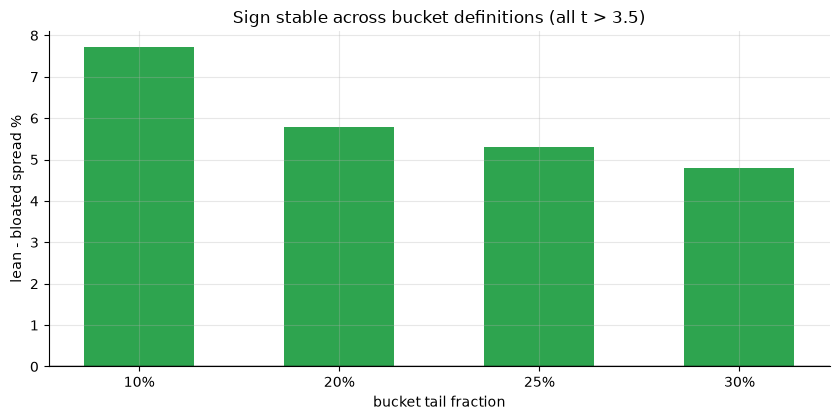

 frac  spread    t  slope_t
 0.10    7.71 3.88    -4.22
 0.20    5.78 3.86    -4.22
 0.25    5.30 3.94    -4.22
 0.30    4.79 3.72    -4.22


In [5]:
sweep = st.robustness_sweep(PANEL, fracs=(0.10, 0.20, 0.25, 0.30))
tab = pd.DataFrame(sweep)
tab['spread'] = tab['spread']*100
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{int(f*100)}%' for f in tab['frac']], tab['spread'], color=GREEN, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('lean - bloated spread %'); ax.set_xlabel('bucket tail fraction')
ax.set_title('Sign stable across bucket definitions (all t > 3.5)')
plt.tight_layout(); plt.show()
print(tab[['frac','spread','t','slope_t']].round(2).to_string(index=False))

> 💡 In plain words: H₄ holds on this world — the spread is positive and *t* > 3.5 at every cut. (Sign-stability on a **real** tape is precisely what the missing data prevents us from checking.)

## 5 · The verdict

- **Signal `WEAK`** — no real tape (synthetic-only ⇒ capped at `WEAK`); on the control H₁–H₄ recovered (spread +5.78%, *t* +3.86; slope-*t* -4.22; flat at the null). Literature supports the direction.
- **Tradability `MIRAGE`** — nothing real to trade; bloated short = hard borrow; synthetic gross +5.78% → net +4.08%.


## 6 · Could you trade it? — costs and the borrow

On the synthetic world the spread survives costs; on the real market there's nothing to trade, and the bloated short leg is the hard-to-borrow tail.

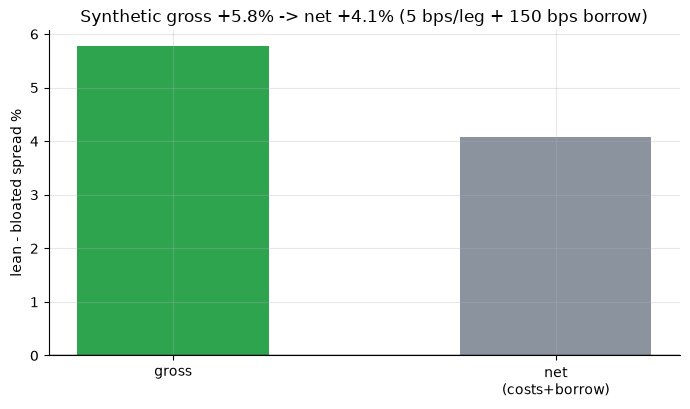

gross +5.78% -> net +4.08%  (synthetic world; no real tape to trade)


In [6]:
b = st.bucket_returns(PANEL, 0.2)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=150.0, holding_years=1.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('lean - bloated spread %')
ax.set_title(f'Synthetic gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 150 bps borrow)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}% -> net {net:+.2f}%  (synthetic world; no real tape to trade)')

> 💡 In plain words: costs shave ~1.7pp on the synthetic world, so the *method* would leave something after frictions — but this is net-of-nothing-real. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print a spread? Plant an overpaid-M&A effect (`ret_alpha < 0`) of increasing strength and watch the firm-level slope-*t* and the long-short *t* move — averaged over 25 seeds so no single lucky seed can fake it.

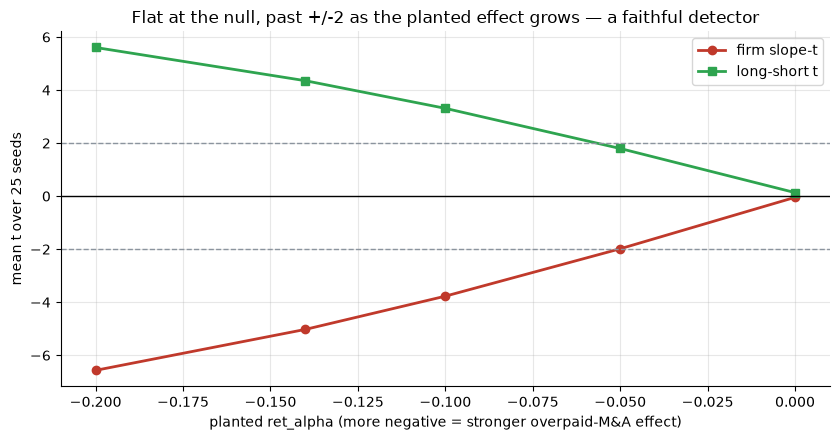

ret_alpha +0.00 -> mean slope-t -0.05 | mean ls-t +0.13
ret_alpha -0.05 -> mean slope-t -1.99 | mean ls-t +1.80
ret_alpha -0.10 -> mean slope-t -3.77 | mean ls-t +3.31
ret_alpha -0.14 -> mean slope-t -5.02 | mean ls-t +4.35
ret_alpha -0.20 -> mean slope-t -6.57 | mean ls-t +5.61


In [7]:
alphas = [0.0, -0.05, -0.10, -0.14, -0.20]
res = [st.synthetic_mean_t(data, ret_alpha=a, n_seeds=25, base_seed=570) for a in alphas]
slope_ts = [r['slope_t'] for r in res]; ls_ts = [r['ls_t'] for r in res]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(alphas, slope_ts, 'o-', c=RED, lw=2, label='firm slope-t')
ax.plot(alphas, ls_ts, 's-', c=GREEN, lw=2, label='long-short t')
ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted ret_alpha (more negative = stronger overpaid-M&A effect)')
ax.set_ylabel('mean t over 25 seeds')
ax.set_title('Flat at the null, past +/-2 as the planted effect grows — a faithful detector')
ax.legend(); plt.tight_layout(); plt.show()
for a, r in zip(alphas, res): print(f'ret_alpha {a:+.2f} -> mean slope-t {r["slope_t"]:+.2f} | mean ls-t {r["ls_t"]:+.2f}')

Both stats sit ≈ 0 at the null and cross ±2 as the planted effect grows — the engine is a faithful detector, catching a real overpaid-M&A effect and staying silent on noise. That is why the honest verdict is **`WEAK`** (validated method + literature support) and not `NONE` — and why it **cannot** be `REAL`: there is no real goodwill/impairment tape to point it at. For the accruals cousins, see [231](../../231-sloan-accruals/) and [522](../../522-percent-operating-accruals/); for a related balance-sheet return puzzle, [540 distress-risk](../../540-distress-risk-anomaly/).